# 01. Análisis Exploratorio de Víctimas del Conflicto Armado

Este notebook contiene un análisis exploratorio del dataset de víctimas del conflicto armado en Colombia.

## Importación de Librerías

Importamos las librerías necesarias para el análisis de datos.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración general
sns.set_theme(style="whitegrid", font_scale=1.2)  # Estilo seaborn

# Opcional: puedes usar estilo matplotlib también (se combinan bien)
plt.style.use('ggplot')  # Cambia por 'fivethirtyeight', 'dark_background', etc. si quieres

# Otras configuraciones
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['axes.grid'] = True

# Ver los estilos disponibles (por si quieres cambiar)
print(plt.style.available)


['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


## Carga del Dataset

Cargamos el dataset de víctimas del conflicto armado desde el archivo CSV.

In [2]:
# Define the relative path to the data file
data_path = '../data/raw/victimas_por_hechos_departamental_20250416.csv'

# Load the dataset
try:
    # Attempt to read with UTF-8 encoding first
    df = pd.read_csv(data_path, encoding='utf-8') 
except UnicodeDecodeError:
    try:
        # Fallback to Latin-1 encoding if UTF-8 fails
        df = pd.read_csv(data_path, encoding='latin1') 
    except Exception as e:
        print(f"Error loading CSV file: {e}")
        df = None # Indicate failure by setting df to None

# Verificar si el dataset se cargó correctamente
if df is not None:
    print(f"Dataset cargado exitosamente. Dimensiones: {df.shape}")
else:
    print("Error al cargar el dataset. Por favor, verifica la ruta y la codificación del archivo.")

Dataset cargado exitosamente. Dimensiones: (2431164, 17)


## Primeras Filas del Dataset

Visualizamos las primeras filas del dataset para entender su estructura.

In [3]:
# Mostrar las primeras filas del dataset
if df is not None:
    print("Primeras 5 filas del dataset:")
    display(df.head())
    print("Ultimas 5 filas del dataset:")
    display(df.tail())
else:
    print("No se puede mostrar las primeras filas porque el dataset no se cargó correctamente.")

Primeras 5 filas del dataset:


,FECHA_CORTE,NOM_RPT,COD_PAIS,PAIS,COD_ESTADO_DEPTO,ESTADO_DEPTO,PARAM_HECHO,HECHO,SEXO,ETNIA,DISCAPACIDAD,CICLO_VITAL,PER_OCU,PER_DECLA,PER_UBIC,PER_SA,EVENTOS
0,2022/03/31 00:00:00.000000000,"REPORTE VICTIMAS POR HECHO, CIFRA DEPARTAMENTA...",48,COLOMBIA,13,Bolivar,5,Desplazamiento forzado,Hombre,Gitano (RROM) (Acreditado RA),Ninguna,entre 18 y 28,3.0,4.0,3.0,3.0,3.0
1,2022/02/28 00:00:00.000000000,"REPORTE VICTIMAS POR HECHO, CIFRA DEPARTAMENTA...",48,COLOMBIA,20,Cesar,5,Desplazamiento forzado,Mujer,Raizal del Archipielago de San Andres y Provid...,Multiple,entre 61 y 100,1.0,NaN,NaN,NaN,1.0
2,2022/04/30 00:00:00.000000000,"REPORTE VICTIMAS POR HECHO, CIFRA DEPARTAMENTA...",48,COLOMBIA,18,Caqueta,5,Desplazamiento forzado,Hombre,Gitano (RROM) (Acreditado RA),Ninguna,entre 29 y 60,2.0,NaN,NaN,NaN,2.0
3,2022/05/31 00:00:00.000000000,"REPORTE VICTIMAS POR HECHO, CIFRA DEPARTAMENTA...",48,COLOMBIA,95,Guaviare,5,Desplazamiento forzado,Hombre,Negro(a) o Afrocolombiano(a),Fisica,entre 61 y 100,11.0,7.0,4.0,4.0,12.0
4,2022/04/30 00:00:00.000000000,"REPORTE VICTIMAS POR HECHO, CIFRA DEPARTAMENTA...",48,COLOMBIA,18,Caqueta,2,Amenaza,Hombre,Indigena (Acreditado RA),Por Establecer,entre 12 y 17,1.0,1.0,1.0,1.0,1.0


Ultimas 5 filas del dataset:


,FECHA_CORTE,NOM_RPT,COD_PAIS,PAIS,COD_ESTADO_DEPTO,ESTADO_DEPTO,PARAM_HECHO,HECHO,SEXO,ETNIA,DISCAPACIDAD,CICLO_VITAL,PER_OCU,PER_DECLA,PER_UBIC,PER_SA,EVENTOS
2431159,28/02/2025,"REPORTE VICTIMAS POR HECHO, CIFRA DEPARTAMENTA...",48,COLOMBIA,18,Caqueta,6,Homicidio,Mujer,Indigena,Ninguna,entre 18 y 28,17.0,12.0,13.0,12.0,18.0
2431160,28/02/2025,"REPORTE VICTIMAS POR HECHO, CIFRA DEPARTAMENTA...",48,COLOMBIA,23,Cordoba,13,Lesiones Personales Fisicas,Mujer,Negro(a) o Afrocolombiano(a),Ninguna,entre 18 y 28,1.0,1.0,1.0,1.0,1.0
2431161,28/02/2025,"REPORTE VICTIMAS POR HECHO, CIFRA DEPARTAMENTA...",48,COLOMBIA,5,Antioquia,1,Acto terrorista / Atentados / Combates / Enfre...,Hombre,Ninguna,Intelectual,entre 60 y 110,4.0,5.0,5.0,4.0,4.0
2431162,28/02/2025,"REPORTE VICTIMAS POR HECHO, CIFRA DEPARTAMENTA...",48,COLOMBIA,66,Risaralda,12,Perdida de Bienes Muebles o Inmuebles,Hombre,Indigena (Acreditado RA),Por Establecer,entre 60 y 110,1.0,1.0,1.0,NaN,1.0
2431163,28/02/2025,"REPORTE VICTIMAS POR HECHO, CIFRA DEPARTAMENTA...",48,COLOMBIA,5,Antioquia,15,Confinamiento,Hombre,Indigena (Acreditado RA),Por Establecer,entre 29 y 59,2.0,2.0,2.0,2.0,3.0


# Ordenamos los datos por ESTADO_DEPTO y SEXO de manera ascendente para encontrar patrones

In [4]:
df_sorted = df.sort_values(by=['ESTADO_DEPTO', 'SEXO'], ascending=[True, False]) 

In [5]:
df_sorted.head(10)

,FECHA_CORTE,NOM_RPT,COD_PAIS,PAIS,COD_ESTADO_DEPTO,ESTADO_DEPTO,PARAM_HECHO,HECHO,SEXO,ETNIA,DISCAPACIDAD,CICLO_VITAL,PER_OCU,PER_DECLA,PER_UBIC,PER_SA,EVENTOS
206,2022/05/31 00:00:00.000000000,"REPORTE VICTIMAS POR HECHO, CIFRA DEPARTAMENTA...",48,COLOMBIA,91,Amazonas,2,Amenaza,Mujer,Ninguna,Ninguna,ND,3.0,6.0,NaN,NaN,3.0
221,2022/03/31 00:00:00.000000000,"REPORTE VICTIMAS POR HECHO, CIFRA DEPARTAMENTA...",48,COLOMBIA,91,Amazonas,5,Desplazamiento forzado,Mujer,Ninguna,Intelectual,entre 29 y 60,1.0,1.0,NaN,NaN,1.0
254,2022/04/30 00:00:00.000000000,"REPORTE VICTIMAS POR HECHO, CIFRA DEPARTAMENTA...",48,COLOMBIA,91,Amazonas,5,Desplazamiento forzado,Mujer,Negro(a) o Afrocolombiano(a),Fisica,entre 29 y 60,NaN,1.0,NaN,NaN,NaN
339,2022/01/31 00:00:00.000000000,"REPORTE VICTIMAS POR HECHO, CIFRA DEPARTAMENTA...",48,COLOMBIA,91,Amazonas,9,Tortura,Mujer,Indigena,Visual,entre 18 y 28,1.0,NaN,NaN,NaN,1.0
417,2022/04/30 00:00:00.000000000,"REPORTE VICTIMAS POR HECHO, CIFRA DEPARTAMENTA...",48,COLOMBIA,91,Amazonas,4,Desaparición forzada,Mujer,Ninguna,Por Establecer,entre 29 y 60,1.0,NaN,1.0,1.0,1.0
447,2022/06/30 00:00:00.000000000,"REPORTE VICTIMAS POR HECHO, CIFRA DEPARTAMENTA...",48,COLOMBIA,91,Amazonas,5,Desplazamiento forzado,Mujer,Indigena (Acreditado RA),Ninguna,entre 29 y 60,172.0,89.0,97.0,87.0,186.0
703,2022/06/30 00:00:00.000000000,"REPORTE VICTIMAS POR HECHO, CIFRA DEPARTAMENTA...",48,COLOMBIA,91,Amazonas,5,Desplazamiento forzado,Mujer,Indigena,Visual,entre 61 y 100,1.0,NaN,NaN,NaN,1.0
1255,2022/05/31 00:00:00.000000000,"REPORTE VICTIMAS POR HECHO, CIFRA DEPARTAMENTA...",48,COLOMBIA,91,Amazonas,2,Amenaza,Mujer,Ninguna,Ninguna,entre 0 y 5,2.0,1.0,1.0,1.0,2.0
1420,2022/05/31 00:00:00.000000000,"REPORTE VICTIMAS POR HECHO, CIFRA DEPARTAMENTA...",48,COLOMBIA,91,Amazonas,5,Desplazamiento forzado,Mujer,Indigena,Intelectual,entre 61 y 100,1.0,NaN,1.0,1.0,2.0
1584,2022/03/31 00:00:00.000000000,"REPORTE VICTIMAS POR HECHO, CIFRA DEPARTAMENTA...",48,COLOMBIA,91,Amazonas,4,Desaparición forzada,Mujer,Indigena,Ninguna,entre 6 y 11,1.0,1.0,1.0,1.0,1.0


## Información del Dataset

Exploramos la información general del dataset, incluyendo tipos de datos y valores no nulos.

In [6]:
# Mostrar información del dataset
if df is not None:
    print("Información del Dataset:")
    df.info()
else:
    print("No se puede mostrar la información porque el dataset no se cargó correctamente.")

Información del Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2431164 entries, 0 to 2431163
Data columns (total 17 columns):
 #   Column            Dtype  
---  ------            -----  
 0   FECHA_CORTE       object 
 1   NOM_RPT           object 
 2   COD_PAIS          int64  
 3   PAIS              object 
 4   COD_ESTADO_DEPTO  int64  
 5   ESTADO_DEPTO      object 
 6   PARAM_HECHO       int64  
 7   HECHO             object 
 8   SEXO              object 
 9   ETNIA             object 
 10  DISCAPACIDAD      object 
 11  CICLO_VITAL       object 
 12  PER_OCU           float64
 13  PER_DECLA         float64
 14  PER_UBIC          float64
 15  PER_SA            float64
 16  EVENTOS           float64
dtypes: float64(5), int64(3), object(9)
memory usage: 315.3+ MB


## Valores Únicos por Columna

A continuación, exploraremos los valores únicos presentes en cada columna del dataset. Esto nos permitirá entender mejor las categorías y la diversidad de datos con los que estamos trabajando, lo cual es fundamental para un análisis más profundo del conflicto armado.

In [7]:
# Función para mostrar los valores únicos de cada columna de manera visualmente atractiva
def mostrar_valores_unicos(dataframe, columnas_excluidas=['FECHA_CORTE', 'PER_OCU', 'PER_DECLA', 'PER_UBIC', 'PER_SA', 'EVENTOS']):
    # Crear un diccionario para almacenar los valores únicos de cada columna
    valores_unicos = {}
    
    # Obtener los valores únicos para cada columna y verificar que no sean nulos
    for columna in dataframe.columns:
        if columna not in columnas_excluidas:
            valores = dataframe[columna].dropna().unique()
            if len(valores) > 0:  # Only add if there are non-null values
                valores_unicos[columna] = valores
    
    # Print total number of columns being displayed
    print(f"\nMostrando valores únicos para {len(valores_unicos)} columnas de un total de {len(dataframe.columns)} columnas\n")
    
    # Mostrar los valores únicos de manera visualmente atractiva
    for columna, valores in valores_unicos.items():
        print(f"\n{'=' * 80}\n{columna} ({len(valores)} valores únicos)\n{'=' * 80}")
        
        # Limitar la cantidad de valores a mostrar si hay demasiados
        max_valores = 200
        if len(valores) > max_valores:
            print(f"Mostrando los primeros {max_valores} valores (de un total de {len(valores)}):\n")
            valores_mostrar = valores[:max_valores]
        else:
            valores_mostrar = valores
        
        # Formatear los valores para una mejor visualización
        for i, valor in enumerate(valores_mostrar):
            print(f"  {i+1}. {valor}")

# Mostrar los valores únicos del dataset
if df is not None:
    mostrar_valores_unicos(df)
else:
    print("No se pueden mostrar los valores únicos porque el dataset no se cargó correctamente.")


Mostrando valores únicos para 11 columnas de un total de 17 columnas


NOM_RPT (2 valores únicos)
  1. REPORTE VICTIMAS POR HECHO, CIFRA DEPARTAMENTAL (SEXO, ETNIA, DISCAPACIDAD, CICLO_VITAL) personas: (Ocurrencia, Declaración, Ubicación, Sujetos Atención y Eventos)
  2. REPORTE VICTIMAS POR HECHO, CIFRA DEPARTAMENTAL (SEXO, ETNIA, DISCAPACIDAD, CICLO_VITAL) personas: (Ocurrencia, Declaraci�n, Ubicaci�n, Sujetos Atenci�n y Eventos)

COD_PAIS (1 valores únicos)
  1. 48

PAIS (1 valores únicos)
  1. COLOMBIA

COD_ESTADO_DEPTO (34 valores únicos)
  1. 13
  2. 20
  3. 18
  4. 95
  5. 19
  6. 25
  7. 99
  8. 66
  9. 44
  10. 50
  11. 52
  12. 17
  13. 68
  14. 0
  15. 8
  16. 54
  17. 85
  18. 70
  19. 27
  20. 76
  21. 86
  22. 11
  23. 41
  24. 63
  25. 97
  26. 94
  27. 47
  28. 81
  29. 23
  30. 15
  31. 5
  32. 73
  33. 91
  34. 88

ESTADO_DEPTO (36 valores únicos)
  1. Bolivar
  2. Cesar
  3. Caqueta
  4. Guaviare
  5. Cauca
  6. Cundinamarca
  7. Vichada
  8. Risaralda
  9. La Guaji

## Estadísticas Descriptivas

Calculamos estadísticas descriptivas para entender la distribución de los datos.

In [8]:
# Calcular estadísticas descriptivas
if df is not None:
    print("Estadísticas Descriptivas:")
    display(df.describe())
else:
    print("No se pueden calcular estadísticas descriptivas porque el dataset no se cargó correctamente.")

Estadísticas Descriptivas:


,COD_PAIS,COD_ESTADO_DEPTO,PARAM_HECHO,PER_OCU,PER_DECLA,PER_UBIC,PER_SA,EVENTOS
count,2431164.0,2.431164e+06,2.431164e+06,1.920090e+06,1.867560e+06,1.974320e+06,1.877696e+06,1.920090e+06
mean,48.0,4.275024e+01,6.631137e+00,2.407835e+02,2.524923e+02,2.285220e+02,1.940017e+02,2.667390e+02
std,0.0,2.987045e+01,4.544691e+00,3.203168e+03,3.185811e+03,3.012718e+03,2.442520e+03,3.587994e+03
min,48.0,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
25%,48.0,1.700000e+01,3.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
50%,48.0,4.400000e+01,5.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00,3.000000e+00
75%,48.0,7.000000e+01,9.000000e+00,1.400000e+01,1.500000e+01,1.400000e+01,1.300000e+01,1.500000e+01
max,48.0,9.900000e+01,2.000000e+01,3.131800e+05,2.979930e+05,2.682440e+05,2.456700e+05,3.600220e+05


## 📌 Listar todos los grupos únicos y su cantidad

In [17]:
# Paso 1: Definir columnas de agrupación
columnas_grupo = [
    'COD_ESTADO_DEPTO','ESTADO_DEPTO', 
    'PARAM_HECHO','HECHO', 
    'SEXO', 'ETNIA', 
    'DISCAPACIDAD', 'CICLO_VITAL'
]

# Paso 2: Obtener lista de grupos únicos
grupos = df.groupby(columnas_grupo).groups.keys()

# Convertir a lista para facilitar copia
grupos_lista = list(grupos)

# Cuántos grupos hay
print(f"Total de grupos: {len(grupos_lista)}")

# Ver los primeros 5 grupos
# for g in grupos_lista[:5]:
for g in grupos_lista[:5]:
    print(g)


Total de grupos: 130398
(0, 'SIN DEFINIR', 1, 'Acto terrorista / Atentados / Combates / Enfrentamientos / Hostigamientos', 'Hombre', 'Afrocolombiano (Acreditado RA)', 'Auditiva', 'entre 29 y 59')
(0, 'SIN DEFINIR', 1, 'Acto terrorista / Atentados / Combates / Enfrentamientos / Hostigamientos', 'Hombre', 'Afrocolombiano (Acreditado RA)', 'Auditiva', 'entre 29 y 60')
(0, 'SIN DEFINIR', 1, 'Acto terrorista / Atentados / Combates / Enfrentamientos / Hostigamientos', 'Hombre', 'Afrocolombiano (Acreditado RA)', 'Fisica', 'entre 29 y 59')
(0, 'SIN DEFINIR', 1, 'Acto terrorista / Atentados / Combates / Enfrentamientos / Hostigamientos', 'Hombre', 'Afrocolombiano (Acreditado RA)', 'Fisica', 'entre 29 y 60')
(0, 'SIN DEFINIR', 1, 'Acto terrorista / Atentados / Combates / Enfrentamientos / Hostigamientos', 'Hombre', 'Afrocolombiano (Acreditado RA)', 'Fisica', 'entre 60 y 110')


## Valores Nulos

Analizamos la presencia de valores nulos en el dataset.

In [10]:
# Verificar valores nulos
if df is not None:
    # Calcular el número de valores nulos por columna
    nulos = df.isnull().sum()
    
    # Calcular el porcentaje de valores nulos
    porcentaje_nulos = (nulos / len(df)) * 100
    
    # Crear un DataFrame con la información de valores nulos
    info_nulos = pd.DataFrame({
        'Valores Nulos': nulos,
        'Porcentaje (%)': porcentaje_nulos
    })
    
    print("Análisis de Valores Nulos:")
    display(info_nulos)
else:
    print("No se puede analizar valores nulos porque el dataset no se cargó correctamente.")

Análisis de Valores Nulos:


,Valores Nulos,Porcentaje (%)
FECHA_CORTE,0,0.000000
NOM_RPT,0,0.000000
COD_PAIS,0,0.000000
PAIS,0,0.000000
COD_ESTADO_DEPTO,0,0.000000
ESTADO_DEPTO,0,0.000000
PARAM_HECHO,0,0.000000
HECHO,0,0.000000
SEXO,0,0.000000
ETNIA,0,0.000000


## Listamos los grupos que hay en el dataset

In [ ]:
columnas_grupo = ['COD_ESTADO_DEPTO','ESTADO_DEPTO', 'PARAM_HECHO','HECHO', 'SEXO',  'ETNIA', 'DISCAPACIDAD', 'CICLO_VITAL']
variables_conteo = ['PER_OCU', 'PER_DECLA', 'PER_UBIC', 'PER_SA', 'EVENTOS']

In [ ]:
#Obtener lista de grupos únicos
grupos = df.groupby(columnas_grupo).groups.keys()

# Convertir a lista para facilitar copia
grupos_lista = list(grupos)

# Convertimos a df para facilitar exportación
grupos_df = pd.DataFrame(grupos, columns=columnas_grupo)

# Cuántos grupos hay
print(f"Total de grupos: {len(grupos_lista)} \n")

# Ver los primeros 5 grupos
for g in grupos_lista[:5]:
    print(g)


Total de grupos: 95561 

(0, 'SIN DEFINIR', 1, 'Acto terrorista / Atentados / Combates / Enfrentamientos / Hostigamientos', 'Hombre', 'Gitano (RROM) (Acreditado RA)', 'Ninguna', 'entre 18 y 28')
(0, 'SIN DEFINIR', 1, 'Acto terrorista / Atentados / Combates / Enfrentamientos / Hostigamientos', 'Hombre', 'Gitano (RROM) (Acreditado RA)', 'Ninguna', 'entre 29 y 59')
(0, 'SIN DEFINIR', 1, 'Acto terrorista / Atentados / Combates / Enfrentamientos / Hostigamientos', 'Hombre', 'Gitano (RROM) (Acreditado RA)', 'Ninguna', 'entre 29 y 60')
(0, 'SIN DEFINIR', 1, 'Acto terrorista / Atentados / Combates / Enfrentamientos / Hostigamientos', 'Hombre', 'Gitano(a) ROM', 'Fisica', 'entre 29 y 59')
(0, 'SIN DEFINIR', 1, 'Acto terrorista / Atentados / Combates / Enfrentamientos / Hostigamientos', 'Hombre', 'Gitano(a) ROM', 'Fisica', 'entre 29 y 60')


In [ ]:
# Paso 4: Exportar con la plantilla estándar
grupos_df.to_csv(
    path_or_buf='../data/processed/grupos_unicos.csv',
    sep=',',
    na_rep='',
    header=True,
    index=False,
    encoding='utf-8',
    quoting=csv.QUOTE_MINIMAL,
    lineterminator=os.linesep,
    quotechar='"',
    decimal='.',
    errors='strict'
)

## Ordenar por grupos y fechas  
Verificamos si existen patrones en los registros dentro de cada grupo.  
Esto nos ayuda a confirmar si los valores corresponden a **outliers reales** o a **conteos acumulados/por evento**.

In [ ]:
# Ordenamos por grupos 
df_sorted = df.sort_values(by=columnas_grupo + ['FECHA_CORTE'])

df_sorted.head()

,FECHA_CORTE,COD_ESTADO_DEPTO,ESTADO_DEPTO,PARAM_HECHO,HECHO,SEXO,ETNIA,DISCAPACIDAD,CICLO_VITAL,PER_OCU,PER_DECLA,PER_UBIC,PER_SA,EVENTOS
1126368,2023-06-30,0,SIN DEFINIR,1,Acto terrorista / Atentados / Combates / Enfre...,Hombre,Gitano (RROM) (Acreditado RA),Ninguna,entre 18 y 28,0,1,0,0,0
1175439,2023-07-31,0,SIN DEFINIR,1,Acto terrorista / Atentados / Combates / Enfre...,Hombre,Gitano (RROM) (Acreditado RA),Ninguna,entre 18 y 28,0,1,0,0,0
1233615,2023-08-31,0,SIN DEFINIR,1,Acto terrorista / Atentados / Combates / Enfre...,Hombre,Gitano (RROM) (Acreditado RA),Ninguna,entre 18 y 28,0,1,0,0,0
1290892,2023-09-30,0,SIN DEFINIR,1,Acto terrorista / Atentados / Combates / Enfre...,Hombre,Gitano (RROM) (Acreditado RA),Ninguna,entre 18 y 28,0,1,0,0,0
1332452,2023-10-31,0,SIN DEFINIR,1,Acto terrorista / Atentados / Combates / Enfre...,Hombre,Gitano (RROM) (Acreditado RA),Ninguna,entre 18 y 28,0,1,0,0,0


In [ ]:
# Ordenamos por grupos 
df_sorted = df.sort_values(by=columnas_grupo + ['FECHA_CORTE'])

df_sorted.head()

,FECHA_CORTE,COD_ESTADO_DEPTO,ESTADO_DEPTO,PARAM_HECHO,HECHO,SEXO,ETNIA,DISCAPACIDAD,CICLO_VITAL,PER_OCU,PER_DECLA,PER_UBIC,PER_SA,EVENTOS
1126368,2023-06-30,0,SIN DEFINIR,1,Acto terrorista / Atentados / Combates / Enfre...,Hombre,Gitano (RROM) (Acreditado RA),Ninguna,entre 18 y 28,0,1,0,0,0
1175439,2023-07-31,0,SIN DEFINIR,1,Acto terrorista / Atentados / Combates / Enfre...,Hombre,Gitano (RROM) (Acreditado RA),Ninguna,entre 18 y 28,0,1,0,0,0
1233615,2023-08-31,0,SIN DEFINIR,1,Acto terrorista / Atentados / Combates / Enfre...,Hombre,Gitano (RROM) (Acreditado RA),Ninguna,entre 18 y 28,0,1,0,0,0
1290892,2023-09-30,0,SIN DEFINIR,1,Acto terrorista / Atentados / Combates / Enfre...,Hombre,Gitano (RROM) (Acreditado RA),Ninguna,entre 18 y 28,0,1,0,0,0
1332452,2023-10-31,0,SIN DEFINIR,1,Acto terrorista / Atentados / Combates / Enfre...,Hombre,Gitano (RROM) (Acreditado RA),Ninguna,entre 18 y 28,0,1,0,0,0


### 📊 Lo que muestran los datos (ejemplo del grupo elegido)

* Grupo: **Antioquia / Desplazamiento forzado / Mujer / Ninguna discapacidad / Visual / entre 18 y 28**
* Variables de conteo: `PER_OCU`, `PER_DECLA`, `PER_UBIC`, `PER_SA`, `EVENTOS`
* Fechas: todos los cortes son **últimos días de mes** (`28/02`, `30/04`, `30/06`, `30/09` …).
* Años: **2022 → 2023 → 2024 → 2025**.
* Hay duplicados exactos en algunos cortes (ejemplo: `29/02/2024` aparece dos veces con los mismos valores).


### 🔎 Posibles interpretaciones

1. **Estructura temporal regular**

   * Los cortes siempre son fin de mes → esto indica que el dataset **probablemente está diseñado como series mensuales** de cierre o corte administrativo.
   * No parece ser un registro "diario de eventos", sino una **consolidación mensual**.

2. **Tendencia general (acumulativo o no)**

   * Ejemplo `EVENTOS`:

     * 2022-02 → 350
     * 2023-02 → 427
     * 2024-02 → 439
     * 2025-02 → 447
   * 🔼 Esto sugiere un **comportamiento acumulativo**: el número sube con el tiempo y nunca se reinicia a cero.
   * Idem para `PER_OCU`, `PER_DECLA`, etc. → todos siguen una **línea ascendente suave**.

3. **Duplicados en la fuente**

   * El `29/02/2024` aparece **dos veces idénticas** → probablemente un error de carga, o que el reporte mensual fue exportado dos veces en tu dataset.
   * Esto deberías **depurarlo** (quedarte con uno solo).

4. **Variaciones pequeñas**

   * El crecimiento es bastante regular, con incrementos pequeños cada año.
   * Ejemplo: `EVENTOS` sube de 350 (2022) → 447 (2025). Un crecimiento del 27% en 3 años.
   * Eso refuerza que es un **conteo acumulado de víctimas registradas** (cada corte incluye lo anterior + lo nuevo).



## Outliers

In [ ]:
# Crear un diccionario para almacenar resultados
resumen_conteo = {}

for col in variables_conteo:
    # Frecuencia de cada valor
    vc = df[col].value_counts().sort_index()
    
    # Total de la variable
    total = df[col].sum()
    
    # Guardar ambos en el diccionario
    resumen_conteo[col] = {
        "Frecuencia de valores": vc,
        "Suma total": total
    }

# Mostrar resumen organizado
for col, info in resumen_conteo.items():
    print(f"\n🔢 Variable: {col}")
    print("-" * 40)
    print("📊 Value Counts:")
    print(info["Frecuencia de valores"])
    print(f"\n🧮 Suma total: {info['Suma total']}")


In [ ]:
# Previsualización del impacto de los outliers
resumen_outliers = []

for col in variables_conteo:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    total = len(df)
    num_outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].shape[0]

    resumen_outliers.append({
        'Variable': col,
        'Q1': round(Q1, 2),
        'Q3': round(Q3, 2),
        'IQR': round(IQR, 2),
        'Límite inferior': round(lower_bound, 2),
        'Límite superior': round(upper_bound, 2),
        'Outliers detectados': num_outliers,
        'Porcentaje Outliers': round((num_outliers / total) * 100, 2)
    })

resumen_df = pd.DataFrame(resumen_outliers)
display(resumen_df)


,Variable,Q1,Q3,IQR,Límite inferior,Límite superior,Outliers detectados,Porcentaje Outliers
0,PER_OCU,1.0,8.0,7.0,-9.5,18.5,418555,17.22
1,PER_DECLA,1.0,8.0,7.0,-9.5,18.5,418324,17.21
2,PER_UBIC,1.0,9.0,8.0,-11.0,21.0,394495,16.23
3,PER_SA,1.0,7.0,6.0,-8.0,16.0,418080,17.20
4,EVENTOS,1.0,9.0,8.0,-11.0,21.0,406537,16.72


In [ ]:
resumen_df.to_csv(
    path_or_buf='../data/processed/resumen_outliers.csv',
    sep=',',
    na_rep='',
    header=True,
    index=False,
    encoding='utf-8',
    quoting=csv.QUOTE_MINIMAL,
    lineterminator=os.linesep,
    quotechar='"',
    decimal='.',
    errors='strict'
)

In [ ]:
# Paso 1: Crear una máscara booleana para marcar outliers en cualquier columna
outlier_mask = pd.Series(False, index=df.index)

for col in variables_conteo:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Marcar como True los registros fuera del rango permitido
    outlier_mask |= (df[col] < lower_bound) | (df[col] > upper_bound)

In [ ]:
# Paso 2: Guardar los registros eliminados (opcional pero recomendable)
df_outliers = df[outlier_mask].copy()

In [ ]:
df_outliers.to_csv(
    path_or_buf='../data/processed/outliers.csv',
    sep=',',
    na_rep='',
    header=True,
    index=False,
    encoding='utf-8',
    quoting=csv.QUOTE_MINIMAL,
    lineterminator=os.linesep,
    quotechar='"',
    decimal='.',
    errors='strict'
)

In [ ]:
# Paso 3: Filtrar el DataFrame conservando solo registros válidos
df = df[~outlier_mask].copy()

In [ ]:
# Paso 4: Reporte rápido
print(f"Registros eliminados: {outlier_mask.sum()}")
print(f"Registros restantes: {len(df)}")

Registros eliminados: 510920
Registros restantes: 1920244


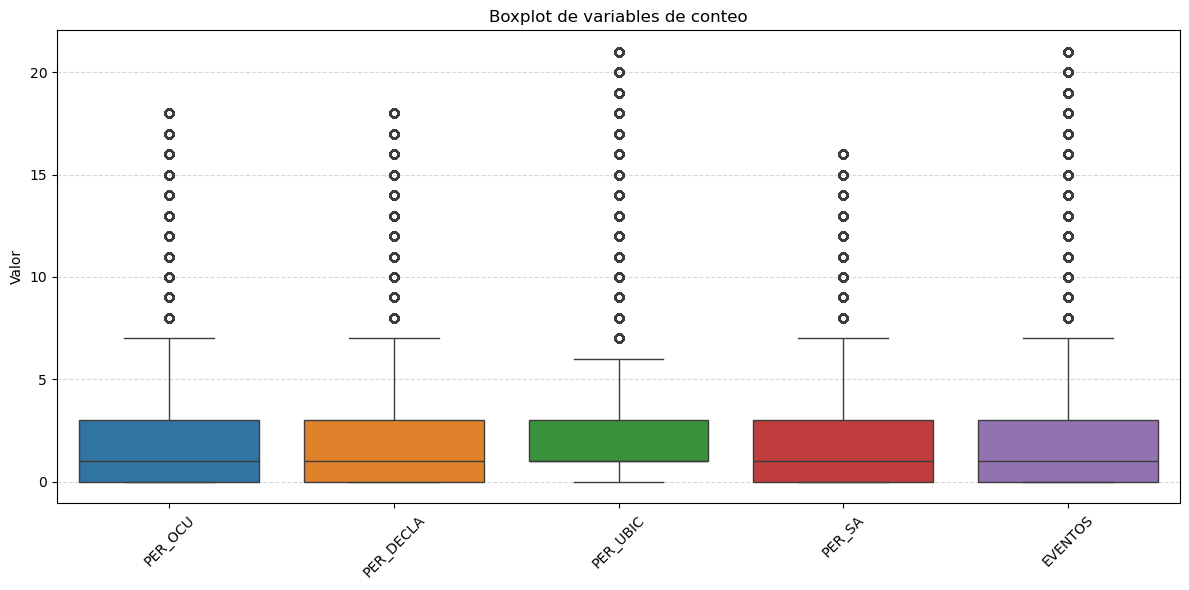

In [ ]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[variables_conteo])
plt.title("Boxplot de variables de conteo")
plt.ylabel("Valor")
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
# Crear un diccionario para almacenar resultados
resumen_conteo = {}

for col in variables_conteo:
    # Frecuencia de cada valor
    vc = df[col].value_counts().sort_index()
    
    # Total de la variable
    total = df[col].sum()
    
    # Guardar ambos en el diccionario
    resumen_conteo[col] = {
        "Frecuencia de valores": vc,
        "Suma total": total
    }

# Mostrar resumen organizado
for col, info in resumen_conteo.items():
    print(f"\n🔢 Variable: {col}")
    print("-" * 40)
    print("📊 Value Counts:")
    print(info["Frecuencia de valores"])
    print(f"\n🧮 Suma total: {info['Suma total']}")


🔢 Variable: PER_OCU
----------------------------------------
📊 Value Counts:
PER_OCU
0     489997
1     629969
2     238812
3     132846
4      88724
5      66370
6      50497
7      39307
8      33141
9      27574
10     22582
11     19811
12     17611
13     15000
14     13249
15     11090
16      9772
17      7860
18      6032
Name: count, dtype: int64

🧮 Suma total: 4884759

🔢 Variable: PER_DECLA
----------------------------------------
📊 Value Counts:
PER_DECLA
0     542853
1     605541
2     233352
3     131047
4      87532
5      64333
6      51771
7      38324
8      32329
9      25698
10     21878
11     19627
12     16525
13     13308
14     10810
15      8656
16      6932
17      5542
18      4186
Name: count, dtype: int64

🧮 Suma total: 4573622

🔢 Variable: PER_UBIC
----------------------------------------
📊 Value Counts:
PER_UBIC
0     455016
1     660205
2     248504
3     140713
4      94271
5      68887
6      51418
7      41642
8      32975
9      27009
10     22399
1

In [ ]:
# Paso 2: Agrupar y sumar valores de conteo
df = df.groupby(columnas_grupo, as_index=False)[variables_conteo].sum()

In [ ]:
# Paso 4: Validar que no queden NaN
print("¿Quedan NaN después del reemplazo?")
print(df[variables_conteo].isna().sum())

¿Quedan NaN después del reemplazo?
PER_OCU      0
PER_DECLA    0
PER_UBIC     0
PER_SA       0
EVENTOS      0
dtype: int64


### ✅ Conclusión preliminar

* Tus datos en este grupo parecen ser **conteos acumulativos** y no valores aislados.
* Los “outliers” que ves (ejemplo duplicados) no son outliers reales, sino **problemas de duplicación en la fuente**.
* El análisis de **diferencias entre fechas consecutivas** (`diff()`) sería más informativo que el valor absoluto → así obtienes la cantidad de nuevos casos reportados en cada mes/trimestre.

## Conclusiones

Resumen de los hallazgos principales del análisis exploratorio.

Después de realizar el análisis exploratorio del dataset de víctimas del conflicto armado en Colombia, podemos destacar los siguientes hallazgos:

1. El dataset contiene información sobre diferentes tipos de hechos victimizantes, con el desplazamiento forzado como el más frecuente.
2. La distribución geográfica muestra que algunos departamentos han sido más afectados que otros por el conflicto armado.
3. Existe una diferencia en la distribución por sexo, lo que indica un impacto diferenciado del conflicto.
4. La distribución por ciclo vital muestra cómo el conflicto ha afectado a diferentes grupos de edad.

Este análisis exploratorio proporciona una base para investigaciones más profundas sobre el impacto del conflicto armado en Colombia.